In [1]:
import re
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, precision_recall_curve
import matplotlib.pyplot as plt
from matplotlib import lines

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [2]:
from pathlib import Path
ROOT = Path('..')
path = ROOT / 'data' / 'processed' / 'draft_enriched_with_contracts.csv'
raw = pd.read_csv(path, low_memory=False)
df = raw.query('2014 <= year <= 2025').copy()
text_cols = ['overview', 'strengths', 'weaknesses']
df[text_cols] = df[text_cols].fillna('')
df['scouting_text'] = (
    df[text_cols].agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
numeric_cols = ['grade']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
df['Pos_Group'] = df['Pos_Group'].fillna('UNKNOWN')
df['is_drafted'] = df['is_drafted'].where(df.year <= 2021)
df = df.loc[(df['grade'] > 0) & (df['scouting_text'].str.strip() != '')].copy()

In [3]:
KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide', 'pass',
    'hard', 'soft', 'strong', 'quick', 'good', 'great', 'up', 'down',
    'off', 'out', 'over', 'through', 'above', 'below',
}
CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'ability', 'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'work', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'level', 'type', 'project', 'potential', 'upside', 'ceiling',
}
PHRASE_BLOCKLIST = [
    'undrafted free agent', 'practice squad', 'free agent', 'early starter',
    'pro bowl', 'late round', 'undrafted free', 'make roster', 'rostered',
]
_base_stops = set(stopwords.words('english'))
NFL_STOPWORDS = (_base_stops - KEEP_WORDS) | CUSTOM_STOPS
_lemmatizer = WordNetLemmatizer()

def nfl_preprocess_no_stitch(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    for phrase in sorted(PHRASE_BLOCKLIST, key=len, reverse=True):
        text = text.replace(phrase, ' ')
    text = re.sub(r'[-–—]', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in NFL_STOPWORDS and len(t) > 1]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

_tag_prefix = {'overview': 'ovr', 'strengths': 'str', 'weaknesses': 'wkn'}
for col, prefix in _tag_prefix.items():
    df[f'{col}_clean'] = df[col].apply(nfl_preprocess_no_stitch)

In [4]:
# ── Section-tagged token representation ──────────────────────────────────────
# Instead of "OVR: token1 token2 STR: token3 token4" (cross-boundary bigrams),
# prefix every token with its section: "ovr_token1 ovr_token2 str_token3 str_token4"
#
# Benefits:
#   - No cross-section boundary bigrams by construction
#   - Bigrams stay within sections: "str_quick str_off_snap"
#   - Every feature is directly interpretable: ovr_* vs str_* vs wkn_*
#   - Can analyse which section drives predictions for each player/position

def build_section_tagged(row):
    parts = []
    for col, prefix in _tag_prefix.items():
        clean = str(row[f'{col}_clean']).strip()
        if clean:
            tagged = [f"{prefix}_{tok}" for tok in clean.split()]
            parts.extend(tagged)
    return ' '.join(parts)

df['scouting_text_tagged'] = df.apply(build_section_tagged, axis=1)
df = df.loc[df['scouting_text_tagged'].str.strip() != ''].copy()

# Raw section token % — added as optional numeric features (no model dependency)
for col in ['overview', 'strengths', 'weaknesses']:
    df[f'{col}_ntok'] = df[f'{col}_clean'].str.split().str.len().fillna(0)
df['_total_ntok'] = (df['overview_ntok'] + df['strengths_ntok'] + df['weaknesses_ntok']).replace(0, 1)
df['str_tok_pct'] = df['strengths_ntok'] / df['_total_ntok']
df['wkn_tok_pct'] = df['weaknesses_ntok'] / df['_total_ntok']
df['ovr_tok_pct'] = df['overview_ntok']  / df['_total_ntok']

# Sanity check
token_counts = df['scouting_text_tagged'].str.split().str.len()
print(f'Players: {len(df)}, tokens/player median: {int(token_counts.median())}')
print(f'Mean str_tok_pct={df.str_tok_pct.mean():.2f}  wkn={df.wkn_tok_pct.mean():.2f}  ovr={df.ovr_tok_pct.mean():.2f}')
print()
sample = df['scouting_text_tagged'].iloc[0]
print('Sample (first 300 chars):')
print(sample[:300])

Players: 5321, tokens/player median: 130
Mean str_tok_pct=0.36  wkn=0.30  ovr=0.34

Sample (first 300 chars):
ovr_compact ovr_every ovr_down ovr_runner ovr_learn ovr_create ovr_yardage ovr_due ovr_limited ovr_blocking ovr_front ovr_gore ovr_come ovr_impressive ovr_bloodline ovr_father ovr_frank ovr_gore ovr_rank ovr_third ovr_career ovr_rushing ovr_attempt ovr_rushing ovr_yard ovr_tough ovr_runner ovr_good 


In [5]:
# Four-way position split — same as two_group_tf_idf
BLOCK    = {'OL', 'DT'}
COVERAGE = {'EDGE', 'DB', 'LB'}
SKILL    = {'WR', 'RB', 'TE', 'UNKNOWN'}
QB_GRP   = {'QB'}

# max_features=1500: vocab is ~3x larger since each token has ovr/str/wkn prefix
# No stop_words needed — cross-boundary artifacts are impossible by design
vectorizer_params = dict(max_features=1500, ngram_range=(2, 3), min_df=3, sublinear_tf=True)
numeric_features  = ['grade']
cat_features      = ['Pos_Group']

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.columns]

def make_text_pipe():
    return Pipeline([
        ('selector', ColumnSelector(['scouting_text_tagged'])),
        ('squeeze',  FunctionTransformer(lambda x: x.squeeze())),
        ('tfidf',    TfidfVectorizer(**vectorizer_params)),
    ])

def make_meta_transformer():
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(),                       numeric_features),
            ('pos', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ],
        remainder='drop',
    )

def make_full_pipe():
    return Pipeline([
        ('features', FeatureUnion([
            ('text', make_text_pipe()),
            ('meta', make_meta_transformer()),
        ])),
        ('rf', RandomForestClassifier(n_estimators=400, class_weight='balanced',
                                      random_state=42, n_jobs=-1)),
    ])

def make_baseline_pipe():
    return Pipeline([
        ('preproc', ColumnTransformer(
            transformers=[
                ('grade', StandardScaler(),                       ['grade']),
                ('pos',   OneHotEncoder(handle_unknown='ignore'), ['Pos_Group']),
            ],
            remainder='drop',
        )),
        ('lr', LogisticRegression(max_iter=2000, solver='liblinear')),
    ])

def fit_baseline(pipe, X, y):
    pos_rate = y.mean()
    w = y*(0.3/pos_rate) + (1-y)*(0.7/(1-pos_rate))
    pipe.fit(X, y, lr__sample_weight=w)

def cv_baseline(pipe, X, y, cv):
    pos_rate = y.mean()
    pw, nw = 0.3/pos_rate, 0.7/(1-pos_rate)
    weights = y*pw + (1-y)*nw
    scores = []
    for tr, te in cv.split(X, y):
        est = clone(pipe)
        est.fit(X.iloc[tr], y.iloc[tr], lr__sample_weight=weights.iloc[tr])
        scores.append(average_precision_score(y.iloc[te], est.predict_proba(X.iloc[te])[:, 1]))
    return np.array(scores)

train_mask = df.year.between(2014, 2021) & df.is_drafted.notna()
train_df   = df[train_mask].copy()
train_df['is_drafted'] = train_df['is_drafted'].astype(int)

block_train    = train_df[train_df['Pos_Group'].isin(BLOCK)].copy()
coverage_train = train_df[train_df['Pos_Group'].isin(COVERAGE)].copy()
skill_train    = train_df[train_df['Pos_Group'].isin(SKILL)].copy()
qb_train       = train_df[train_df['Pos_Group'].isin(QB_GRP)].copy()

y_block, y_coverage, y_skill, y_qb = (
    block_train['is_drafted'],
    coverage_train['is_drafted'],
    skill_train['is_drafted'],
    qb_train['is_drafted'],
)

for label, tr, y in [('Block   ', block_train, y_block),
                      ('Coverage', coverage_train, y_coverage),
                      ('Skill   ', skill_train, y_skill),
                      ('QB      ', qb_train, y_qb)]:
    print(f"{label} — {len(tr)} players, {int(y.sum())} positives ({y.mean():.1%})")

Block    — 865 players, 483 positives (55.8%)
Coverage — 1341 players, 789 positives (58.8%)
Skill    — 1016 players, 507 positives (49.9%)
QB       — 156 players, 88 positives (56.4%)


## Sleeper Contract Analysis: Can text find UDFA-risk players who get signed?

**Reframed research question:** Among players scouts grade below 6.0 (UDFA / very late round risk), can scouting text identify which ones actually get signed to an NFL contract?

- **Sleeper zone:** grade < 6.0 — scouts think these players are borderline undraftable
- **Outcome:** `made_it_contract` — got any NFL contract (drafted *or* signed as UDFA)
- **Base rate:** ~17–18% within grade < 6.0 (vs ~50% for `is_drafted` at grade < 6.5)
- **Models are refit fresh** on this outcome within the sleeper zone only


In [19]:

# ── Cell 1: Build sleeper zone datasets with made_it_contract outcome ─────────
from sklearn.model_selection import StratifiedKFold, KFold

SLEEPER_GRADE = 6.0
K_EVAL = 25

# made_it_contract lives on df (raw load) but was not the training target.
# Merge it back using the original df index, restricted to training years.
contract_series = (
    df.loc[df.year.between(2014, 2021), 'made_it_contract']
    .map({True: 1, False: 0, 1: 1, 0: 0})  # handle bool or int
)

def build_sleeper_group(train_df):
    """
    Filter a position group's training df to grade < SLEEPER_GRADE,
    attach made_it_contract, drop rows with unknown outcome.
    Returns (sub_df, y) or (None, None) if too small.
    """
    sub = train_df[train_df['grade'] < SLEEPER_GRADE].copy()
    sub = sub.join(contract_series.rename('contract'), how='left')
    sub = sub.dropna(subset=['contract'])
    sub['contract'] = sub['contract'].astype(int)
    y = sub['contract']
    return sub, y

SLEEPER_GROUPS = {}
print(f"Sleeper zone  (grade < {SLEEPER_GRADE})  —  made_it_contract outcome")
print(f"{'Group':<10}  {'N':>5}  {'Positives':>10}  {'Base rate':>10}")
print("-" * 42)

for grp, train_df in [('Block',    block_train),
                       ('Coverage', coverage_train),
                       ('Skill',    skill_train),
                       ('QB',       qb_train)]:
    sub, y = build_sleeper_group(train_df)
    if sub is None or len(sub) < K_EVAL or y.sum() < 5:
        print(f"{grp:<10}  — too few positives, skipping —")
        continue
    SLEEPER_GROUPS[grp] = (sub, y)
    print(f"{grp:<10}  {len(sub):>5}  {int(y.sum()):>10}  {y.mean():>10.1%}")


Sleeper zone  (grade < 6.0)  —  made_it_contract outcome
Group           N   Positives   Base rate
------------------------------------------
Block         539         129       23.9%
Coverage      870         224       25.7%
Skill         670         105       15.7%
QB             94          13       13.8%


In [20]:

# ── Cell 2: Refit models on made_it_contract within sleeper zone + evaluate ───
# Models are trained fresh here — NOT reusing is_drafted OOF scores.
# Use StratifiedKFold where possible; fall back to KFold if too few positives/fold.

from sklearn.metrics import average_precision_score

def safe_cv(y, n_splits=5):
    """Use StratifiedKFold unless any fold would have < 2 positives."""
    n_pos = int(y.sum())
    if n_pos >= n_splits * 2:
        return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    return KFold(n_splits=min(n_splits, n_pos), shuffle=True, random_state=42)

def prec_rec_at_k(y_true, scores, k):
    y_arr = np.asarray(y_true)
    idx   = np.argsort(scores)[::-1][:min(k, len(y_arr))]
    prec  = y_arr[idx].mean()
    rec   = y_arr[idx].sum() / max(y_arr.sum(), 1)
    return prec, rec

CONTRACT_RESULTS = {}

print(f"Sleeper zone (grade < {SLEEPER_GRADE}) — made_it_contract OOF evaluation")
print(f"{'Group':<10}  {'Base%':>6}  "
      f"{'── Grade only ──':^30}  {'── Text+Grade ──':^30}")
print(f"{'':10}  {'':6}  "
      f"{'Prec@25':>9}  {'Rec@25':>8}  {'PR-AUC':>9}  "
      f"{'Prec@25':>9}  {'Rec@25':>8}  {'PR-AUC':>9}")
print("-" * 80)

for grp, (sub, y) in SLEEPER_GROUPS.items():
    cv_grp = safe_cv(y)

    # Grade-only OOF
    b_oof = cross_val_predict(
        make_baseline_pipe(), sub[['grade', 'Pos_Group']], y,
        cv=cv_grp, method='predict_proba'
    )[:, 1]

    # Text+grade OOF
    t_oof = cross_val_predict(
        make_full_pipe(), sub, y,
        cv=cv_grp, method='predict_proba'
    )[:, 1]

    base_rate   = y.mean()
    b_prec, b_rec = prec_rec_at_k(y, b_oof, K_EVAL)
    t_prec, t_rec = prec_rec_at_k(y, t_oof, K_EVAL)
    b_prauc       = average_precision_score(y, b_oof)
    t_prauc       = average_precision_score(y, t_oof)

    CONTRACT_RESULTS[grp] = dict(
        sub=sub, y=y, b_oof=b_oof, t_oof=t_oof,
        base_rate=base_rate,
        b_prec=b_prec, b_rec=b_rec, b_prauc=b_prauc,
        t_prec=t_prec, t_rec=t_rec, t_prauc=t_prauc,
    )

    print(f"{grp:<10}  {base_rate:>6.1%}  "
          f"{b_prec:>9.1%}  {b_rec:>8.1%}  {b_prauc:>9.4f}  "
          f"{t_prec:>9.1%}  {t_rec:>8.1%}  {t_prauc:>9.4f}")

print(f"\nBase rate ~17% means Prec@25 > 30% is meaningful lift over random selection.")


Sleeper zone (grade < 6.0) — made_it_contract OOF evaluation
Group        Base%         ── Grade only ──                ── Text+Grade ──       
                      Prec@25    Rec@25     PR-AUC    Prec@25    Rec@25     PR-AUC
--------------------------------------------------------------------------------
Block        23.9%      36.0%      7.0%     0.3094      48.0%      9.3%     0.3193
Coverage     25.7%      28.0%      3.1%     0.3584      36.0%      4.0%     0.3395
Skill        15.7%      12.0%      2.9%     0.1833      24.0%      5.7%     0.1941
QB           13.8%      20.0%     38.5%     0.2614      24.0%     46.2%     0.2861

Base rate ~17% means Prec@25 > 30% is meaningful lift over random selection.


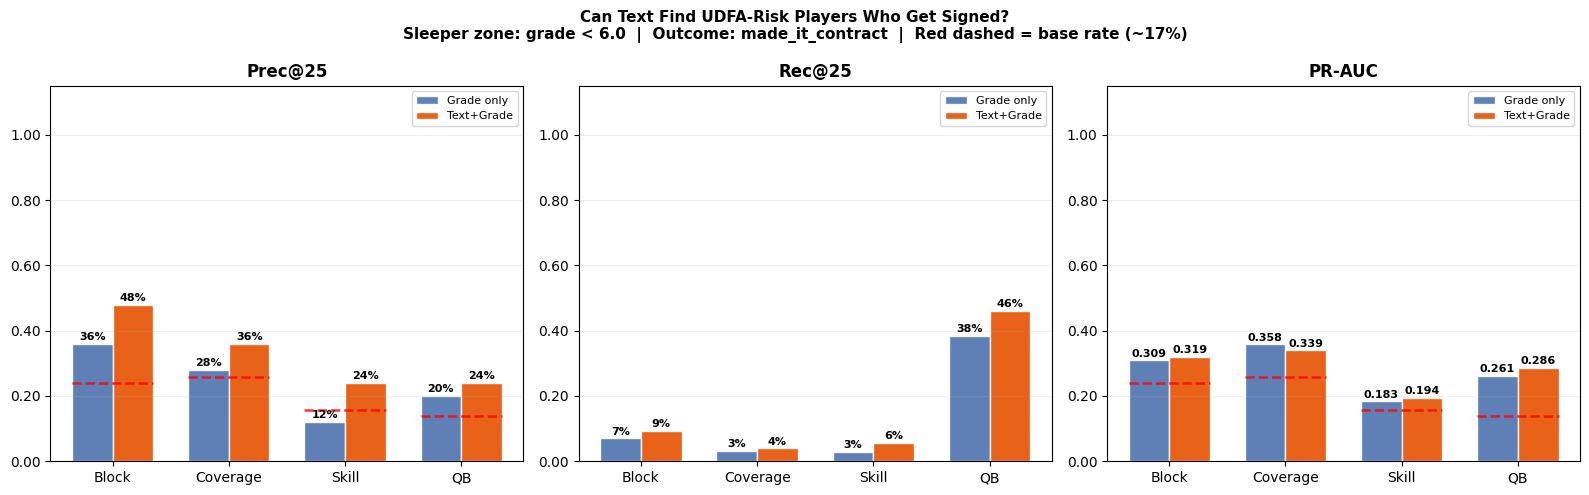

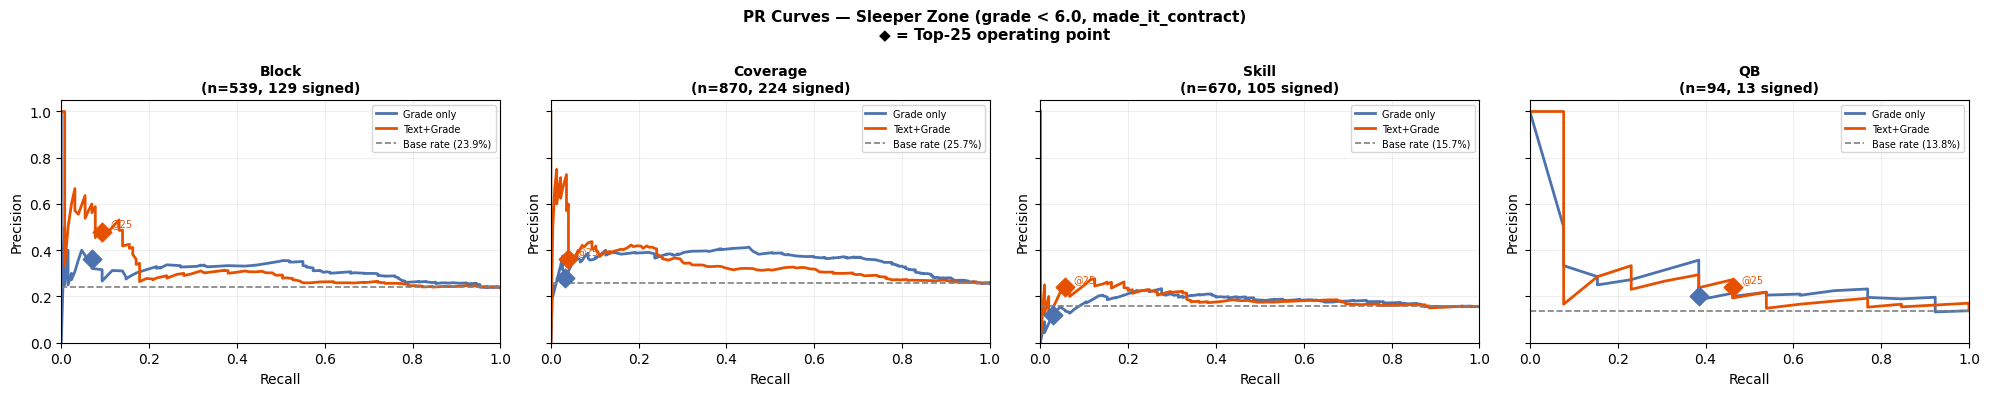

In [21]:

# ── Cell 3: Bar chart + PR curves ────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve

COLOR_BASE = '#4C72B0'
COLOR_TEXT = '#E65100'

res_df = pd.DataFrame([
    dict(Group=g, Base_rate=v['base_rate'],
         Base_Prec=v['b_prec'], Base_Rec=v['b_rec'], Base_PRAUC=v['b_prauc'],
         Text_Prec=v['t_prec'], Text_Rec=v['t_rec'], Text_PRAUC=v['t_prauc'])
    for g, v in CONTRACT_RESULTS.items()
])

# ── Grouped bars ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('Prec@25', 'Base_Prec', 'Text_Prec', True),
           ('Rec@25',  'Base_Rec',  'Text_Rec',  False),
           ('PR-AUC',  'Base_PRAUC','Text_PRAUC', True)]

for ax, (label, bc, tc, show_br) in zip(axes, metrics):
    x, w = np.arange(len(res_df)), 0.35
    b_bars = ax.bar(x - w/2, res_df[bc], width=w, color=COLOR_BASE, alpha=0.9,
                    label='Grade only', edgecolor='white')
    t_bars = ax.bar(x + w/2, res_df[tc], width=w, color=COLOR_TEXT, alpha=0.9,
                    label='Text+Grade', edgecolor='white')
    for bar in list(b_bars) + list(t_bars):
        h = bar.get_height()
        fmt = f'{h:.0%}' if label != 'PR-AUC' else f'{h:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                fmt, ha='center', va='bottom', fontsize=8, fontweight='bold')
    if show_br:
        for i, row in res_df.iterrows():
            ax.plot([i - w, i + w], [row['Base_rate'], row['Base_rate']],
                    color='red', lw=1.8, ls='--', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(res_df['Group'], fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{v:.0%}' if label != 'PR-AUC' else f'{v:.2f}'))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

fig.suptitle(f'Can Text Find UDFA-Risk Players Who Get Signed?\n'
             f'Sleeper zone: grade < {SLEEPER_GRADE}  |  Outcome: made_it_contract  |  '
             f'Red dashed = base rate (~17%)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── PR curves ─────────────────────────────────────────────────────────────────
n = len(CONTRACT_RESULTS)
fig2, axes2 = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
if n == 1: axes2 = [axes2]

for ax, (grp, v) in zip(axes2, CONTRACT_RESULTS.items()):
    for scores, color, lbl in [(v['b_oof'], COLOR_BASE, 'Grade only'),
                                (v['t_oof'], COLOR_TEXT,  'Text+Grade')]:
        p_c, r_c, _ = precision_recall_curve(v['y'], scores)
        ax.plot(r_c, p_c, color=color, lw=2, label=lbl)
    ax.axhline(v['base_rate'], color='grey', ls='--', lw=1.2,
               label=f"Base rate ({v['base_rate']:.1%})")
    # mark @K operating points
    for scores, color, pk, rk in [(v['b_oof'], COLOR_BASE, v['b_prec'], v['b_rec']),
                                   (v['t_oof'], COLOR_TEXT,  v['t_prec'], v['t_rec'])]:
        ax.scatter([rk], [pk], color=color, s=90, zorder=5, marker='D')
    ax.annotate(f'@{K_EVAL}', xy=(v['t_rec'], v['t_prec']),
                xytext=(6, 4), textcoords='offset points', fontsize=7, color=COLOR_TEXT)
    ax.set_title(f"{grp}\n(n={len(v['sub'])}, {int(v['y'].sum())} signed)",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(fontsize=7); ax.grid(alpha=0.2)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

fig2.suptitle(f'PR Curves — Sleeper Zone (grade < {SLEEPER_GRADE}, made_it_contract)\n'
              f'◆ = Top-{K_EVAL} operating point',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


Delta Analysis — grade < 6.0, outcome: made_it_contract, K=25

Block  (base rate = 23.9%)
  Overlap (both lists):           0  →  nan% signed
  Text rescues (text, not grade): 25  →  48.0% signed  ← text adds
  Grade finds  (grade, not text): 25  →  36.0% signed  ← text removes
  Lift: +12.0%  ✓ text swap correct

  Text rescues (not in grade top-25):
     player_name Pos_Group  grade  text_score  base_score  contract
Charles Leno Jr.        OL  5.800       0.562       0.319         1
     Niles Scott        DT  5.500       0.552       0.175         0
Austin Wentworth        OL  5.600       0.550       0.247         0
   Corey Linsley        OL  5.600       0.520       0.229         1
       Ryan Groy        OL  5.800       0.507       0.332         1
  Brandon Linder        OL  5.800       0.505       0.297         1
   Dakota Dozier        OL  5.900       0.492       0.376         0
    Justin Britt        OL  5.600       0.485       0.229         1
  Arie Kouandjio        OL  5.800 

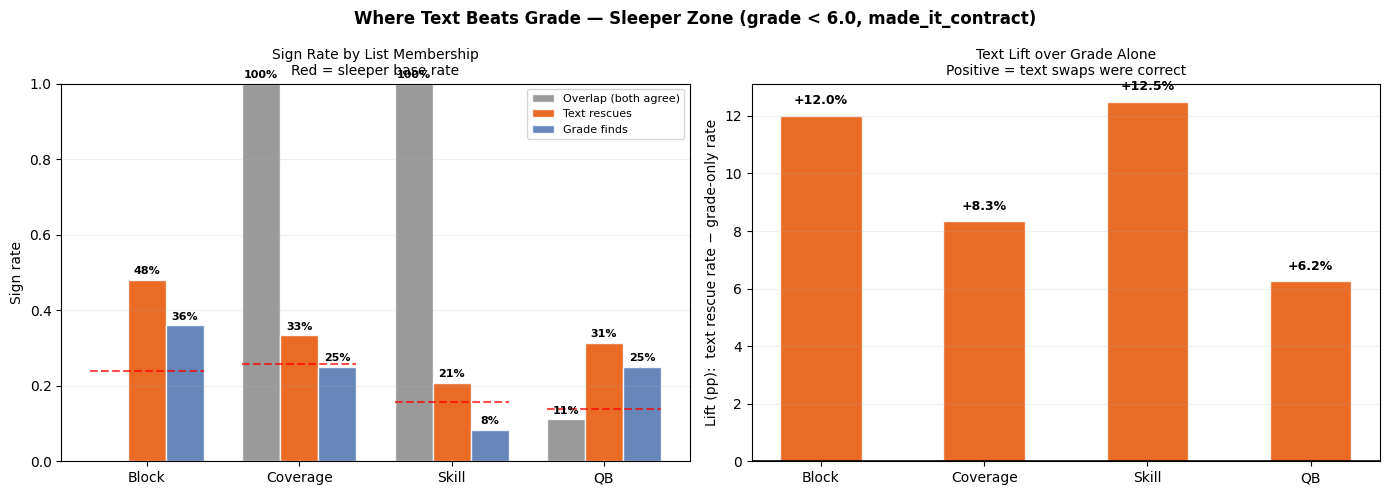

In [22]:

# ── Cell 4: Delta analysis — where does text beat grade? ─────────────────────
# Top-K by text+grade vs top-K by grade-only within the sleeper zone.
# "Text rescues" = in text top-K but not grade top-K → did they get signed?
# "Grade finds"  = in grade top-K but not text top-K → did they get signed?
# Lift = text rescue rate − grade-only rate (positive = text swap was correct)

print(f"Delta Analysis — grade < {SLEEPER_GRADE}, outcome: made_it_contract, K={K_EVAL}")
print("=" * 70)

delta_records = []

for grp, v in CONTRACT_RESULTS.items():
    sub, y = v['sub'], v['y']
    t_oof, b_oof = v['t_oof'], v['b_oof']
    base_rate = v['base_rate']

    sl = sub[['player_name', 'Pos_Group', 'grade', 'contract', 'year']].copy().reset_index(drop=True)
    sl['text_score'] = t_oof
    sl['base_score'] = b_oof

    text_top  = set(sl.nlargest(K_EVAL, 'text_score').index)
    grade_top = set(sl.nlargest(K_EVAL, 'base_score').index)

    overlap_idx    = text_top & grade_top
    text_only_idx  = text_top - grade_top
    grade_only_idx = grade_top - text_top

    def sr(idx):
        if not idx: return np.nan, 0
        vals = sl.loc[list(idx), 'contract'].values
        return vals.mean(), len(vals)

    ov_r, ov_n = sr(overlap_idx)
    tx_r, tx_n = sr(text_only_idx)
    gr_r, gr_n = sr(grade_only_idx)
    lift = tx_r - gr_r if not (np.isnan(tx_r) or np.isnan(gr_r)) else np.nan

    print(f"\n{grp}  (base rate = {base_rate:.1%})")
    print(f"  Overlap (both lists):         {ov_n:>3}  →  {ov_r:.1%} signed")
    print(f"  Text rescues (text, not grade):{tx_n:>3}  →  {tx_r:.1%} signed  ← text adds")
    print(f"  Grade finds  (grade, not text):{gr_n:>3}  →  {gr_r:.1%} signed  ← text removes")
    print(f"  Lift: {lift:+.1%}  {'✓ text swap correct' if lift > 0 else '✗ text swap incorrect'}")

    delta_records.append(dict(Group=grp, Base_rate=base_rate,
                              Overlap_n=ov_n, Overlap_rate=ov_r,
                              Text_n=tx_n,    Text_rate=tx_r,
                              Grade_n=gr_n,   Grade_rate=gr_r,
                              Lift=lift))

    rescued = sl.loc[list(text_only_idx)].sort_values('text_score', ascending=False)
    demoted = sl.loc[list(grade_only_idx)].sort_values('base_score', ascending=False)

    print(f"\n  Text rescues (not in grade top-{K_EVAL}):")
    print(rescued[['player_name','Pos_Group','grade','text_score','base_score','contract']]
          .to_string(index=False, float_format='{:.3f}'.format))

    print(f"\n  Grade finds (dropped by text):")
    print(demoted[['player_name','Pos_Group','grade','text_score','base_score','contract']]
          .to_string(index=False, float_format='{:.3f}'.format))

# ── Summary chart ─────────────────────────────────────────────────────────────
delta_df = pd.DataFrame(delta_records).dropna(subset=['Text_rate', 'Grade_rate'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x, w = np.arange(len(delta_df)), 0.25
ax.bar(x - w,   delta_df['Overlap_rate'], width=w, color='#888888',
       label='Overlap (both agree)', alpha=0.85, edgecolor='white')
ax.bar(x,       delta_df['Text_rate'],    width=w, color=COLOR_TEXT,
       label='Text rescues', alpha=0.85, edgecolor='white')
ax.bar(x + w,   delta_df['Grade_rate'],   width=w, color=COLOR_BASE,
       label='Grade finds', alpha=0.85, edgecolor='white')
for i, row in delta_df.iterrows():
    for val, off in [(row['Overlap_rate'], -w), (row['Text_rate'], 0), (row['Grade_rate'], w)]:
        if not np.isnan(val):
            ax.text(i + off, val + 0.01, f'{val:.0%}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.plot([i - 1.5*w, i + 1.5*w], [row['Base_rate'], row['Base_rate']],
            color='red', lw=1.5, ls='--', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(delta_df['Group'], fontsize=10)
ax.set_ylim(0, 1.0); ax.set_ylabel('Sign rate')
ax.set_title('Sign Rate by List Membership\nRed = sleeper base rate', fontsize=10)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

ax2 = axes[1]
colors_lift = [COLOR_TEXT if v > 0 else COLOR_BASE for v in delta_df['Lift']]
bars = ax2.bar(np.arange(len(delta_df)), delta_df['Lift'] * 100,
               color=colors_lift, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, delta_df['Lift']):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + (0.3 if h >= 0 else -1.5),
             f'{val:+.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.axhline(0, color='black', lw=1.2)
ax2.set_xticks(np.arange(len(delta_df)))
ax2.set_xticklabels(delta_df['Group'], fontsize=10)
ax2.set_ylabel('Lift (pp):  text rescue rate − grade-only rate')
ax2.set_title('Text Lift over Grade Alone\nPositive = text swaps were correct', fontsize=10)
ax2.grid(axis='y', alpha=0.2)

fig.suptitle(f'Where Text Beats Grade — Sleeper Zone (grade < {SLEEPER_GRADE}, made_it_contract)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
